<img src="https://res.cloudinary.com/dtizipxds/image/upload/q_auto/f_auto/v1776264397/banner_yvwajv.png" width="100%">


In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn xgboost

# Dimensions in Machine Learning

This notebook explains dimensionality in a practical way:

1. What a "dimension" means.
2. Why higher dimensions are harder for many ML tasks.
3. Visual intuition using multiple datasets.
4. A model experiment (XGBoost-style) showing performance as dimensions increase.
5. How reducing dimensions can improve generalization.


In [1]:
# Imports and setup
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import (
    make_blobs,
    make_classification,
    load_wine,
    load_breast_cancer,
    load_digits,
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.ensemble import HistGradientBoostingClassifier

sns.set_theme(style='whitegrid')
np.random.seed(42)


In [2]:
# Model selection: use XGBoost if available, otherwise fallback
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    MODEL_NAME = 'XGBoost'
except Exception:
    HAS_XGB = False
    MODEL_NAME = 'HistGradientBoosting (fallback)'

print('Model used in experiments:', MODEL_NAME)


Model used in experiments: XGBoost


## 1) Visual Intuition: 1D vs 2D vs 3D

A dimension is one independent feature axis.
- 1D: one feature
- 2D: two features (points on a plane)
- 3D: three features (points in space)


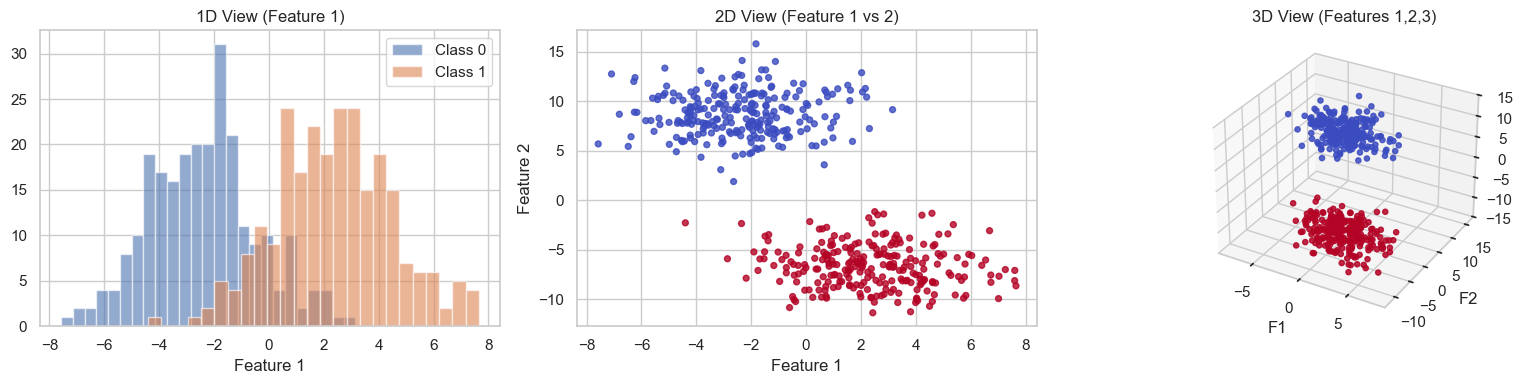

In [3]:
# Generate a simple 3-feature dataset so we can inspect 1D/2D/3D views
X_blob, y_blob = make_blobs(
    n_samples=500,
    n_features=3,
    centers=2,
    cluster_std=2.2,
    random_state=42,
)

fig = plt.figure(figsize=(16, 4))

# 1D view
ax1 = fig.add_subplot(1, 3, 1)
ax1.hist(X_blob[y_blob == 0, 0], bins=25, alpha=0.6, label='Class 0')
ax1.hist(X_blob[y_blob == 1, 0], bins=25, alpha=0.6, label='Class 1')
ax1.set_title('1D View (Feature 1)')
ax1.set_xlabel('Feature 1')
ax1.legend()

# 2D view
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap='coolwarm', s=18, alpha=0.8)
ax2.set_title('2D View (Feature 1 vs 2)')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')

# 3D view
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(X_blob[:, 0], X_blob[:, 1], X_blob[:, 2], c=y_blob, cmap='coolwarm', s=14, alpha=0.85)
ax3.set_title('3D View (Features 1,2,3)')
ax3.set_xlabel('F1')
ax3.set_ylabel('F2')
ax3.set_zlabel('F3')

plt.tight_layout()
plt.show()


## 2) Curse of Dimensionality: Distances Become Less Informative

In high dimensions, points tend to become similarly distant from each other.
A simple signal: the ratio between nearest and farthest neighbor distances gets closer to 1.


In [4]:
def nearest_farthest_ratio(n_samples=400, dims=(2, 5, 10, 30, 100, 300), random_state=42):
    rng = np.random.default_rng(random_state)
    rows = []

    for d in dims:
        X = rng.normal(size=(n_samples, d))
        D = euclidean_distances(X, X)
        np.fill_diagonal(D, np.nan)
        nearest = np.nanmin(D, axis=1)
        farthest = np.nanmax(D, axis=1)
        ratio = nearest / farthest

        rows.append({
            'dimensions': d,
            'mean_ratio': np.mean(ratio),
            'std_ratio': np.std(ratio),
        })

    return pd.DataFrame(rows)

ratio_df = nearest_farthest_ratio()
ratio_df


,dimensions,mean_ratio,std_ratio
0,2,0.026103,0.018637
1,5,0.148042,0.042978
2,10,0.277970,0.045628
3,30,0.505926,0.034639
4,100,0.694461,0.023891
5,300,0.811963,0.015858


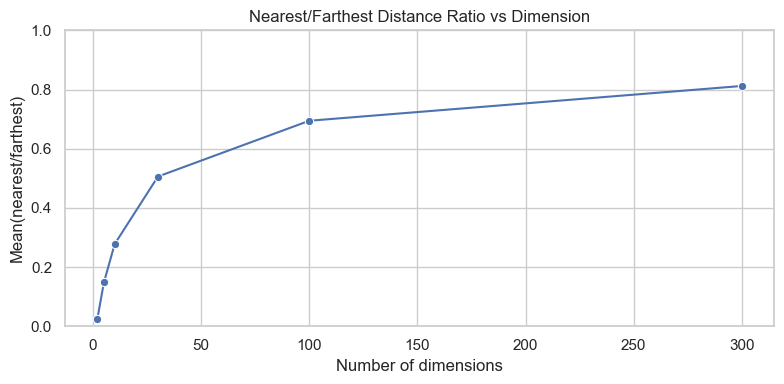

In [5]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=ratio_df, x='dimensions', y='mean_ratio', marker='o')
plt.title('Nearest/Farthest Distance Ratio vs Dimension')
plt.ylabel('Mean(nearest/farthest)')
plt.xlabel('Number of dimensions')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 3) Multiple Real Datasets and Their Effective Dimensions

We will inspect three datasets with different feature counts:
- Wine (13 features)
- Breast Cancer (30 features)
- Digits (64 features)

Then use PCA to see how much variance is captured by the first few components.


In [6]:
# Load multiple datasets
wine = load_wine(as_frame=True)
cancer = load_breast_cancer(as_frame=True)
digits = load_digits(as_frame=True)

datasets = {
    'Wine': (wine.data, wine.target),
    'Breast Cancer': (cancer.data, cancer.target),
    'Digits': (digits.data, digits.target),
}

summary_rows = []
for name, (X, y) in datasets.items():
    summary_rows.append({
        'Dataset': name,
        'Samples': X.shape[0],
        'Features': X.shape[1],
        'Classes': len(np.unique(y)),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Dataset,Samples,Features,Classes
0,Wine,178,13,3
1,Breast Cancer,569,30,2
2,Digits,1797,64,10


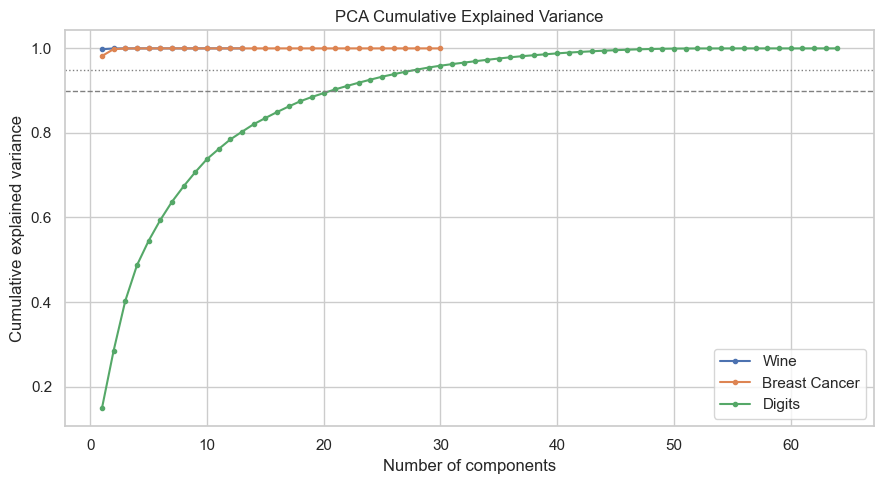

In [7]:
# PCA cumulative explained variance curves
plt.figure(figsize=(9, 5))

for name, (X, _) in datasets.items():
    pca = PCA().fit(X)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='.', label=name)

plt.axhline(0.90, color='gray', linestyle='--', linewidth=1)
plt.axhline(0.95, color='gray', linestyle=':', linewidth=1)
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.tight_layout()
plt.show()


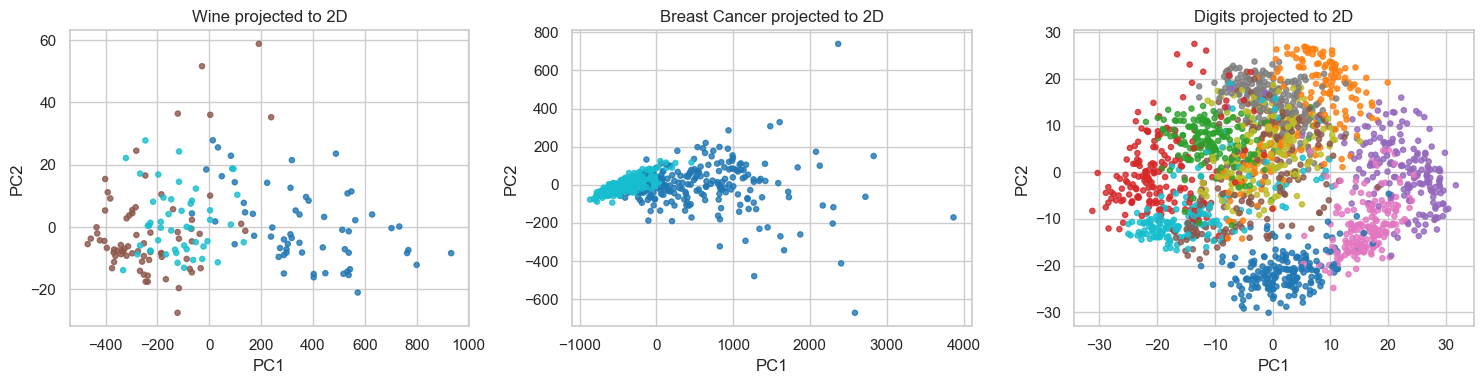

In [8]:
# 2D PCA projections for visual inspection
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (X, y)) in zip(axes, datasets.items()):
    pca2 = PCA(n_components=2, random_state=42)
    X_2d = pca2.fit_transform(X)
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=14, alpha=0.8)
    ax.set_title(f'{name} projected to 2D')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()


## 4) Model Experiment: Increasing Noise Dimensions

We create synthetic classification datasets where the number of informative features is fixed,
but we keep adding noisy dimensions.

If dimensionality hurts learning, test performance should decline and overfitting gap should increase.


In [9]:
def make_model(random_state=42):
    if HAS_XGB:
        return XGBClassifier(
            n_estimators=160,
            max_depth=4,
            learning_rate=0.06,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            random_state=random_state,
            eval_metric='logloss',
            n_jobs=-1,
        )
    return HistGradientBoostingClassifier(
        max_depth=4,
        learning_rate=0.06,
        max_iter=220,
        random_state=random_state,
    )


def run_dimension_experiment(dim_list=(10, 20, 40, 80, 150, 300), seeds=(1, 2, 3, 4, 5)):
    rows = []

    for d in dim_list:
        for seed in seeds:
            X, y = make_classification(
                n_samples=900,
                n_features=d,
                n_informative=8,
                n_redundant=2,
                n_repeated=0,
                n_clusters_per_class=2,
                class_sep=1.0,
                flip_y=0.03,
                random_state=seed,
            )

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.30, stratify=y, random_state=seed
            )

            model = make_model(random_state=seed)

            t0 = time.time()
            model.fit(X_train, y_train)
            fit_seconds = time.time() - t0

            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)

            train_acc = accuracy_score(y_train, train_pred)
            test_acc = accuracy_score(y_test, test_pred)

            rows.append({
                'dimensions': d,
                'seed': seed,
                'train_acc': train_acc,
                'test_acc': test_acc,
                'generalization_gap': train_acc - test_acc,
                'test_f1': f1_score(y_test, test_pred),
                'fit_seconds': fit_seconds,
            })

    return pd.DataFrame(rows)

exp_df = run_dimension_experiment()
exp_df.head()


,dimensions,seed,train_acc,test_acc,generalization_gap,test_f1,fit_seconds
0,10,1,0.996825,0.948148,0.048677,0.948905,0.178618
1,10,2,0.995238,0.907407,0.087831,0.911661,0.061001
2,10,3,0.992063,0.855556,0.136508,0.851711,0.062412
3,10,4,0.988889,0.914815,0.074074,0.914498,0.056996
4,10,5,0.990476,0.951852,0.038624,0.952381,0.057003


In [10]:
summary = exp_df.groupby('dimensions', as_index=False).agg({
    'train_acc': 'mean',
    'test_acc': 'mean',
    'test_f1': 'mean',
    'generalization_gap': 'mean',
    'fit_seconds': 'mean',
})
summary


,dimensions,train_acc,test_acc,test_f1,generalization_gap,fit_seconds
0,10,0.992698,0.915556,0.915831,0.077143,0.083206
1,20,0.997460,0.900741,0.900452,0.096720,0.111052
2,40,1.000000,0.885926,0.884729,0.114074,0.123000
3,80,1.000000,0.886667,0.887530,0.113333,0.202065
4,150,1.000000,0.871111,0.870755,0.128889,0.342181
5,300,1.000000,0.868889,0.864467,0.131111,0.669179


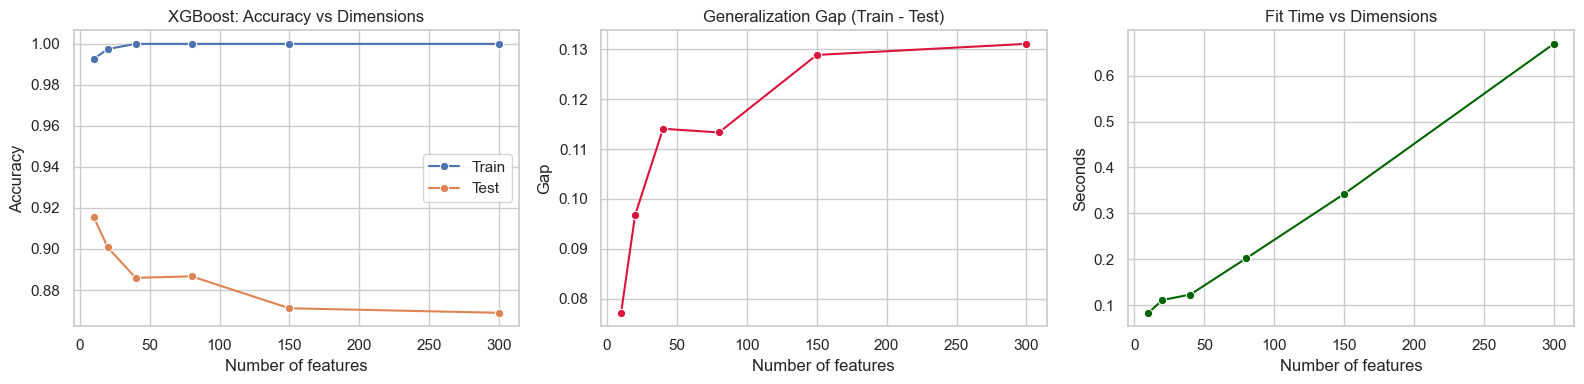

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=summary, x='dimensions', y='train_acc', marker='o', label='Train', ax=axes[0])
sns.lineplot(data=summary, x='dimensions', y='test_acc', marker='o', label='Test', ax=axes[0])
axes[0].set_title(f'{MODEL_NAME}: Accuracy vs Dimensions')
axes[0].set_ylabel('Accuracy')

sns.lineplot(data=summary, x='dimensions', y='generalization_gap', marker='o', color='crimson', ax=axes[1])
axes[1].set_title('Generalization Gap (Train - Test)')
axes[1].set_ylabel('Gap')

sns.lineplot(data=summary, x='dimensions', y='fit_seconds', marker='o', color='darkgreen', ax=axes[2])
axes[2].set_title('Fit Time vs Dimensions')
axes[2].set_ylabel('Seconds')

for ax in axes:
    ax.set_xlabel('Number of features')

plt.tight_layout()
plt.show()


## 5) Same High-Dim Dataset, Then Reduce Dimensions

Now we take a high-dimensional dataset and compare:
- Raw features
- PCA-reduced features
- SelectKBest (top statistical features)

This shows how lowering dimensionality can recover performance.


In [12]:
# One high-dimensional dataset
X_hd, y_hd = make_classification(
    n_samples=1200,
    n_features=300,
    n_informative=10,
    n_redundant=10,
    flip_y=0.04,
    class_sep=1.0,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_hd, y_hd, test_size=0.30, stratify=y_hd, random_state=42
)

# 1) Raw model
raw_model = make_model(random_state=42)
raw_model.fit(X_train, y_train)
raw_pred = raw_model.predict(X_test)

# 2) PCA -> 20 dimensions
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

pca_model = make_model(random_state=42)
pca_model.fit(X_train_pca, y_train)
pca_pred = pca_model.predict(X_test_pca)

# 3) SelectKBest -> 20 dimensions
selector = SelectKBest(score_func=f_classif, k=20)
X_train_k = selector.fit_transform(X_train, y_train)
X_test_k = selector.transform(X_test)

k_model = make_model(random_state=42)
k_model.fit(X_train_k, y_train)
k_pred = k_model.predict(X_test_k)

compare_df = pd.DataFrame([
    {
        'Setup': 'Raw (300 dims)',
        'Test Accuracy': accuracy_score(y_test, raw_pred),
        'Test F1': f1_score(y_test, raw_pred),
    },
    {
        'Setup': 'PCA (20 dims)',
        'Test Accuracy': accuracy_score(y_test, pca_pred),
        'Test F1': f1_score(y_test, pca_pred),
    },
    {
        'Setup': 'SelectKBest (20 dims)',
        'Test Accuracy': accuracy_score(y_test, k_pred),
        'Test F1': f1_score(y_test, k_pred),
    },
])

compare_df


,Setup,Test Accuracy,Test F1
0,Raw (300 dims),0.861111,0.864865
1,PCA (20 dims),0.872222,0.876344
2,SelectKBest (20 dims),0.872222,0.878307


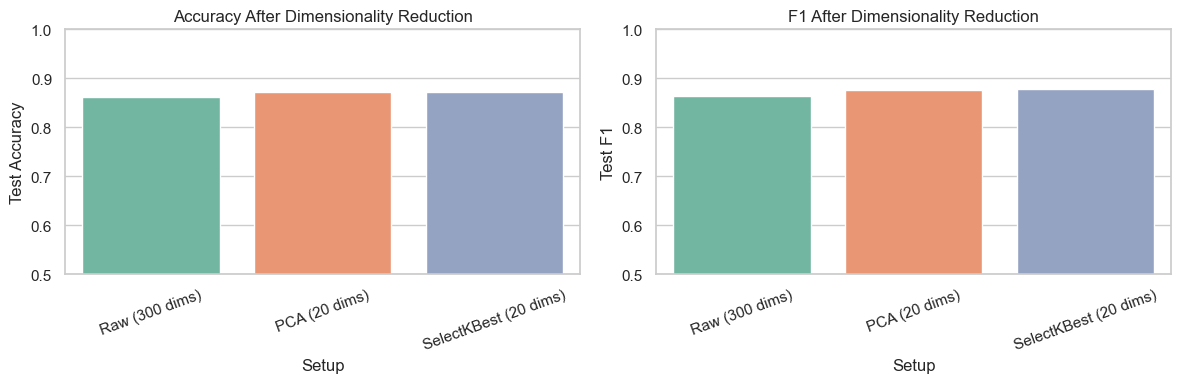

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=compare_df, x='Setup', y='Test Accuracy', ax=axes[0], palette='Set2')
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_title('Accuracy After Dimensionality Reduction')

sns.barplot(data=compare_df, x='Setup', y='Test F1', ax=axes[1], palette='Set2')
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_title('F1 After Dimensionality Reduction')

plt.tight_layout()
plt.show()


## Final Takeaways

- Dimensionality is not just a bigger feature vector; it changes geometry and learning behavior.
- As dimensions rise with limited signal, models face harder generalization and often larger train-test gaps.
- Reducing dimensions (PCA / feature selection) can improve robustness and speed.

Use dimensionality reduction as a standard part of your tabular ML toolbox, especially when features are many and noisy.
